# Data Extraction — *All of Us* Fitbit data

**SIADS 699 Capstone · Team Sleep Deprived**
Sophia Boettcher · Auston Balwinski · Hunter Belous · Jared Fox

---

Five queries against the *All of Us* Fitbit tables, exported as Parquet. The notebook then applies the
inclusion rules from [`src/features.py`](../src/features.py), checks what each rule costs,
aggregates to one row per participant, restricts to the participants whose targets are measured
precisely enough to model, and writes `data/feats_data.pkl`.

Runs only in the *All of Us* Researcher Workbench — it needs Controlled Tier credentials. Every
output is an aggregate.

---
## 1 · Setup

`q()` runs a query and returns a DataFrame; `cost()` dry-runs it and returns the GB it would scan.
Nothing new gets executed before it has been costed. The CDR is read from `WORKSPACE_CDR`, which the
Workbench sets on every runtime, so the notebook carries no hardcoded project id.

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display
from google.cloud import bigquery

# Works whether the kernel starts in notebooks/ or at the repo root.
REPO = Path.cwd()
if not (REPO / "src").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from src import viz
from src.features import (
    MIN_EXTRACT_NIGHTS,
    MIN_MODEL_NIGHTS,
    MIN_SLEEP_DATE,
    add_targets,
    clean_demographics,
    clean_sleep,
    clean_steps,
    make_participant_features,
    restrict_to_measured,
    sleep_funnel,
)
from src.models import CATEGORICAL_COLS, FEATURE_COLS, GROUP_COLS

# The three night- and day-level figures are published from here.
FIGURES = REPO / "reports" / "figures"

# Set by the Workbench runtime. The fallback is the CDR this analysis was run
# against, kept only so the notebook is readable outside the Workbench — it
# will not resolve without Controlled Tier access.
CDR = os.environ.get("WORKSPACE_CDR", "<project>.R2025Q4R6")

client = bigquery.Client()


def _render(sql):
    """Substitute {COHORT}, {CDR} and every PARAMS key into a query template.

    COHORT goes first: it expands to SQL that itself carries {CDR} and
    {min_minutes}, which the later substitutions then resolve.
    """
    for key, value in {"COHORT": COHORT, "CDR": CDR, **PARAMS}.items():
        sql = sql.replace("{" + key + "}", str(value))
    return sql


def q(sql):
    """Run a query, return a DataFrame."""
    return client.query(_render(sql)).to_dataframe()


def cost(sql):
    """GB this query would scan. Dry-run anything new before you execute it."""
    cfg = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
    job = client.query(_render(sql), job_config=cfg)
    return round(job.total_bytes_processed / 1e9, 3)

### Parameters


In [2]:
PARAMS = {
    # Cohort scoping only. min_nights is clean_sleep()'s floor, read from
    # features.py so the two cannot drift.
    "min_nights":   MIN_EXTRACT_NIGHTS,
    "min_minutes":  240,
    "ref_date":     "2025-01-01",
    "bmi_concept":  3038553,
}

---
## 2 · The cohort

A participant is in the cohort if they have at least `min_nights` distinct nights of main sleep of at
least `min_minutes`.

Each of the two granular queries semi-joins against this definition. Without it the exports
carry every participant with any Fitbit data at all.

In [3]:
COHORT = """
  SELECT person_id
  FROM `{CDR}.sleep_daily_summary`
  WHERE is_main_sleep = 'true'
    AND minute_asleep >= {min_minutes}
  GROUP BY person_id
  HAVING COUNT(DISTINCT sleep_date) >= {min_nights}
"""

---
## 3 · Granular queries

Two queries, each returning one row per person-night or person-day: restrict to the cohort, then
deduplicate.

**Deduplication.** `sleep_daily_summary` is not one row per person-night, 
a little over 119,000 person-nights carry two or more rows, and without the `QUALIFY` clause those
nights are counted twice. `activity_summary` gets the same treatment.

### Chunk 1 · Sleep nights

One row per person-night, with the four columns `clean_sleep()` expects. Naps are dropped here, which
is what makes `(person_id, sleep_date)` a well-defined deduplication key.

- `is_main_sleep` is a **STRING**. `clean_sleep()` tests `== True`, which is `False` for
  the string `'true'`, so the query casts it to a real `BOOL`.
- `minute_asleep > 0` is a corruption guard, not a duration bound.

In [4]:
CHUNK_1_SLEEP_NIGHTS = """
SELECT
  person_id,
  sleep_date,
  is_main_sleep = 'true' AS is_main_sleep,   -- cast STRING -> BOOL for clean_sleep()
  minute_asleep
FROM `{CDR}.sleep_daily_summary`
WHERE is_main_sleep = 'true'
  AND minute_asleep > 0
  AND person_id IN ({COHORT})
QUALIFY ROW_NUMBER() OVER (PARTITION BY person_id, sleep_date
                           ORDER BY minute_asleep DESC) = 1
"""

### Chunk 2 · Activity

One row per person-day.

In [5]:
CHUNK_2_ACTIVITY_DAYS = """
SELECT
  person_id,
  `date`,
  steps
FROM `{CDR}.activity_summary`
WHERE steps IS NOT NULL
  AND person_id IN ({COHORT})
QUALIFY ROW_NUMBER() OVER (PARTITION BY person_id, `date`
                           ORDER BY steps DESC) = 1
"""

---
## 4 · Person-level queries

Demographics, BMI, and survey responses have one row per
participant native shape. They are not cohort-scoped, because
`make_participant_features()` inner-joins on them and the join does the restricting.

In [6]:
CHUNK_4_DEMOGRAPHICS = """
SELECT
  PERSON_ID AS person_id,
  GENDER    AS gender,
  RACE      AS race,
  ETHNICITY AS ethnicity,
  DATE_DIFF(DATE '{ref_date}', DATE(DATE_OF_BIRTH), YEAR) AS age
FROM `{CDR}.ds_person`
"""

CHUNK_5_BMI = """
SELECT
  person_id,
  AVG(value_as_number) AS bmi
FROM `{CDR}.measurement`
WHERE measurement_concept_id = {bmi_concept}
  AND value_as_number BETWEEN 12 AND 70
GROUP BY person_id
"""

CHUNK_6_SURVEY = """
WITH ranked AS (
  SELECT
    person_id, question, answer,
    ROW_NUMBER() OVER (PARTITION BY person_id, question
                       ORDER BY survey_datetime DESC) AS rn
  FROM `{CDR}.ds_survey`
  WHERE question IN (
    'Income: Annual Income',
    'Education Level: Highest Grade',
    'Employment: Employment Status',
    'Overall Health: General Health'
  )
    AND answer NOT IN ('PMI: Skip', 'PMI: Prefer Not To Answer',
                       'PMI: Dont Know')
)
SELECT
  person_id,
  MAX(IF(question = 'Income: Annual Income',          answer, NULL)) AS income_bracket,
  MAX(IF(question = 'Education Level: Highest Grade', answer, NULL)) AS education,
  MAX(IF(question = 'Employment: Employment Status',  answer, NULL)) AS employment,
  MAX(IF(question = 'Overall Health: General Health', answer, NULL)) AS self_rated_health
FROM ranked
WHERE rn = 1
GROUP BY person_id
"""

---
## 5 · Cost, then run

Dry-run everything before executing it.

In [7]:
CHUNKS = {
    "sleep_nights":  CHUNK_1_SLEEP_NIGHTS,
    "activity_days": CHUNK_2_ACTIVITY_DAYS,
    "demographics":  CHUNK_4_DEMOGRAPHICS,
    "bmi":           CHUNK_5_BMI,
    "survey":        CHUNK_6_SURVEY,
}

# The two tables exported at native grain, with the key each is unique on.
GRAIN_KEYS = {
    "sleep_nights":  ["person_id", "sleep_date"],
    "activity_days": ["person_id", "date"],
}

pd.DataFrame(
    [{"chunk": name, "gb_scanned": cost(sql)} for name, sql in CHUNKS.items()]
).set_index("chunk")

,gb_scanned
chunk,
sleep_nights,1.395
activity_days,3.016
demographics,0.045
bmi,16.490
survey,18.607


In [8]:
extracts = {name: q(sql) for name, sql in CHUNKS.items()}

for name, df in extracts.items():
    print(f"  {name:<16} {len(df):>12,} rows   {df.shape[1]} cols")

  sleep_nights       39,008,187 rows   4 cols
  activity_days      61,781,567 rows   3 cols
  demographics          738,044 rows   5 cols
  bmi                   593,902 rows   2 cols
  survey                736,948 rows   5 cols


---
## 6 · Export

The two granular tables are written as they are; the three person-level tables are joined first,
since that is the shape `make_participant_features()` takes as its `demo_df`. Parquet rather than CSV
because it preserves the `sleep_date` and `is_main_sleep` dtypes exactly and is roughly four times
smaller.

In [9]:
for name in GRAIN_KEYS:
    destination = REPO / "data" / f"{name}.parquet"
    destination.parent.mkdir(exist_ok=True)
    extracts[name].to_parquet(destination, index=False)
    print(f"  wrote {len(extracts[name]):>12,} rows -> {destination.relative_to(REPO)}")

  wrote   39,008,187 rows -> data/sleep_nights.parquet
  wrote   61,781,567 rows -> data/activity_days.parquet


In [10]:
person = (
    extracts["demographics"]
    .merge(extracts["bmi"],    on="person_id", how="left")
    .merge(extracts["survey"], on="person_id", how="left")
)
assert person["person_id"].is_unique, "duplicate person_id after merge"

person.to_parquet(REPO / "data" / "person_level.parquet", index=False)
print(f"  wrote {len(person):>12,} rows -> data/person_level.parquet")

  wrote      738,044 rows -> data/person_level.parquet


---
## 7 · Grain validation

Is each exported table actually unique on the key it claims? `sleep_daily_summary` is not one row
per person-night as its name suggests, so this is the check that the `QUALIFY` clauses did their
job. `person_level.parquet` is checked by the assertion in section 6 rather than here, since it has no
native grain to lose.

In [11]:
pd.DataFrame([
    {
        "table":           name,
        "rows":            len(extracts[name]),
        "people":          extracts[name]["person_id"].nunique(),
        "rows_per_person": round(len(extracts[name]) / extracts[name]["person_id"].nunique(), 1),
        "grain_unique":    not extracts[name].duplicated(key).any(),
    }
    for name, key in GRAIN_KEYS.items()
]).set_index("table")

,rows,people,rows_per_person,grain_unique
table,,,,
sleep_nights,39008187,59596,654.5,True
activity_days,61781567,59233,1043.0,True


---
## 8 · Why the analysis window starts at 2017

`clean_sleep()` drops everything before `MIN_SLEEP_DATE`.

Fitbit introduced PPG-based sleep staging in 2017. Mean nightly sleep steps down across that
boundary and nightly SD steps down with it. Restricting to 2017 onward costs about 8.5% of nights but under 1% of participants.

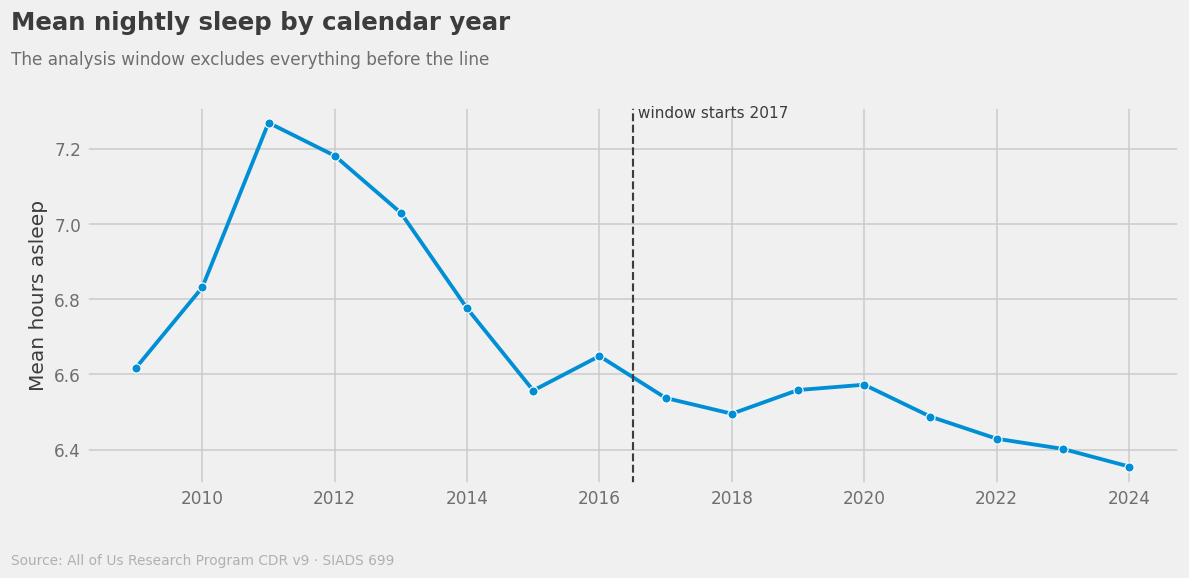

,nights,people,mean_hours,sd_hours
year,,,,
2009,1961,33,6.618,1.935
2010,5024,95,6.831,2.029
2011,18034,326,7.269,2.082
2012,54137,923,7.181,3.309
2013,165179,2407,7.029,2.261
2014,413191,4965,6.776,2.226
2015,1056328,8460,6.557,2.169
2016,1621954,10601,6.649,1.964
2017,2019738,12060,6.537,1.86


In [12]:
# Three columns only: the raw frame is ~39M rows and assigning onto it copies
# every column. astype rather than pd.to_datetime
by_year = (
    pd.DataFrame({
        "year":  extracts["sleep_nights"]["sleep_date"].astype("datetime64[ns]").dt.year,
        "hours": extracts["sleep_nights"]["minute_asleep"] / 60,
        "pid":   extracts["sleep_nights"]["person_id"],
    })
    .groupby("year")
    .agg(nights=("hours", "size"), people=("pid", "nunique"),
         mean_hours=("hours", "mean"), sd_hours=("hours", "std"))
    .reset_index()
)

fig = viz.plot_yearly_sleep(by_year, cutoff_year=pd.Timestamp(MIN_SLEEP_DATE).year)
viz.save_figure(fig, "fig_yearly_sleep", FIGURES)
display(fig)

by_year.set_index("year").round(3)

---
## 9 · Cleaning

`clean_sleep()` restricts to nights from **2017-01-01** onward, then keeps main-sleep nights of
4–12 hours, drops participants with under 70% valid nights, and requires at least 4.
`clean_steps()` applies the same window, then keeps days of 100–100,000 steps, minimum 4 days.

The 2017 window is applied first, so the 70% validity rule judges each
participant on the window being analysed rather than on nights that get discarded anyway. A
participant whose early history is poor but whose recent tracking is clean now survives.

`sleep_funnel()` reports what each rule costs

`clean_sleep()` returns `person_id`, `sleep_date`, `hours_asleep`, since
`is_main_sleep` is constant `True` once cleaned and `minute_asleep` is just `hours_asleep × 60`.

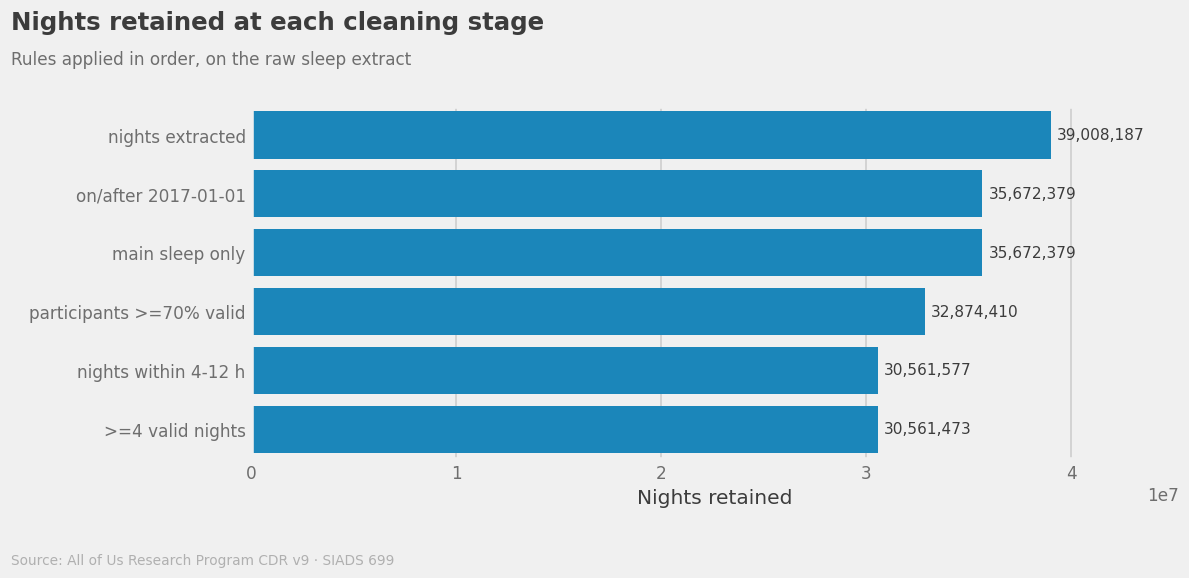

,nights,people,people_lost
stage,,,
nights extracted,39008187,59596,0
on/after 2017-01-01,35672379,59092,-504
main sleep only,35672379,59092,0
participants >=70% valid,32874410,48746,-10346
nights within 4-12 h,30561577,48746,0
>=4 valid nights,30561473,48688,-58


In [13]:
sleep_clean = clean_sleep(extracts["sleep_nights"])
steps_clean = clean_steps(extracts["activity_days"])

funnel = sleep_funnel(extracts["sleep_nights"])
assert funnel.iloc[-1]["nights"] == len(sleep_clean), "funnel diverged from clean_sleep()"

fig = viz.plot_funnel(funnel)
viz.save_figure(fig, "fig_funnel", FIGURES)
display(fig)

funnel.set_index("stage")

In [14]:
pd.DataFrame([
    {"stage": stage, "rows": len(df), "people": df["person_id"].nunique()}
    for stage, df in [
        ("days extracted",    extracts["activity_days"]),
        ("after clean_steps", steps_clean),
    ]
]).set_index("stage")

,rows,people
stage,,
days extracted,61781567,59233
after clean_steps,48437222,58779


### Demographics

`clean_demographics()` recodes the raw survey strings: race and ethnicity collapse into
`race_ethnicity` (Hispanic/Latino overrides race, which keeps the participants who reported Hispanic
ethnicity but skipped the race question out of `Unknown`), income becomes a three-level
`income_tier`, and the rest are normalized against the `*_MAP` dicts in
[`src/features.py`](../src/features.py). Values not in a map become `NaN` rather than passing
through, so a new survey answer surfaces as missing.

The person-level extract is **not** cohort-scoped, the inner join in section 11 is what restricts it. 
So the audit of this recode waits until section 13, once the cohort exists.

In [15]:
person = clean_demographics(person)

print(f"{len(person):,} people in the person-level extract "
      f"({person.shape[1]} columns) — the join in §11 restricts this to the cohort")

738,044 people in the person-level extract (9 columns) — the join in §11 restricts this to the cohort


---
## 10 · Night-level checks

The retained nights, before aggregation collapses the grain. This is the only view of the raw
night-level distribution in the project.

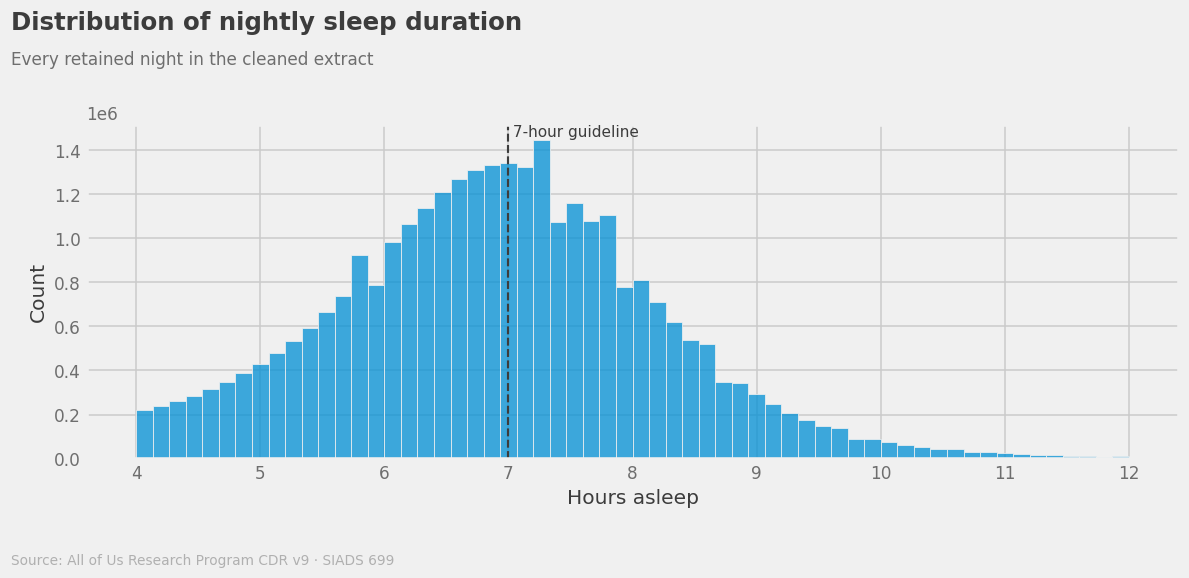

In [16]:
fig = viz.plot_sleep_distribution(sleep_clean)
viz.save_figure(fig, "fig_sleep_distribution", FIGURES)
fig

---
## 11 · Participant-level features

`make_participant_features()` aggregates sleep and steps and inner-joins the person-level frame, the cohort gate. 
`add_targets()` names the two outcomes: duration is mean nightly hours, consistency is the within-person SD.

In [17]:
features = add_targets(make_participant_features(sleep_clean, steps_clean, person))

assert features["person_id"].is_unique, "duplicate person_id in features"
print(f"{len(features):,} participants x {features.shape[1]} columns")

48,688 participants x 22 columns


---
## 12 · Cohort restriction

`target_sleep_consistency` is a within-person SD, so it is an estimate whose precision depends on how
many nights it was computed from. The sampling variance of an SD from *n* observations is about
σ²/2(n−1), which is what the table below computes.

The extract is restricted to **≥30 nights** before it is written. The threshold comes from that
formula rather than from its effect on any score: below it, over a quarter of what a model would be
asked to predict is measurement noise.

The earlier `MIN_EXTRACT_NIGHTS = 4` is a separate floor that does a
different job. The evidence for the second one needs the first one to be loose.

In [18]:
bands = pd.cut(features["n_valid_nights"].astype(float), [3, 10, 30, 100, 365, 3000],
               labels=["4-10", "11-30", "31-100", "101-365", "366+"])

noise_rows = []
for band, band_df in features.groupby(bands, observed=True):
    sd = band_df["target_sleep_consistency"].astype(float)
    nights = band_df["n_valid_nights"].astype(float)
    noise_var = (sd.mean() ** 2 / (2 * (nights - 1))).mean()   # sampling variance of an SD

    noise_rows.append({"nights tracked": band, "n": f"{len(band_df):,}",
                       "var(target)": round(sd.var(), 4),
                       "est. noise var": round(noise_var, 4),
                       "noise share": f"{noise_var / sd.var():.0%}"})

pd.DataFrame(noise_rows).set_index("nights tracked")

,n,var(target),est. noise var,noise share
nights tracked,,,,
4-10,"1,080",0.2702,0.1433,53%
11-30,"2,457",0.1505,0.0439,29%
31-100,"5,133",0.1090,0.0136,12%
101-365,"13,858",0.0931,0.0035,4%
366+,"26,160",0.0768,0.0008,1%


In [19]:
cohort = restrict_to_measured(features)

kept = len(cohort) / len(features)
print(f"{len(features):,} -> {len(cohort):,} participants "
      f"at >= {MIN_MODEL_NIGHTS} nights ({kept:.1%} kept)")
print(f"minimum nights now: {cohort['n_valid_nights'].min()}")

48,688 -> 45,259 participants at >= 30 nights (93.0% kept)
minimum nights now: 30


---
## 13 · Cohort audit

Everything below runs on `cohort` rather than on the
pre-restriction frame, so these are the distributions and the missingness the models actually see.

`person_id` is dropped from the summary to hide participant identifiers.

In [20]:
cohort.drop(columns="person_id").describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,45259.0,56.71166,16.10709,20.0,43.0,58.0,71.0,89.0
bmi,41135.0,29.352371,7.00172,13.182162,24.3,27.986953,33.046714,68.579993
mean_sleep_hrs,45259.0,6.887831,0.646318,4.647458,6.439994,6.86327,7.304576,10.135049
std_sleep_hrs,45259.0,1.15033,0.296394,0.282274,0.940245,1.121224,1.330284,2.615535
n_valid_nights,45259.0,674.077554,616.058266,30.0,212.0,430.0,992.0,2784.0
pct_short_sleep,45259.0,0.25427,0.175236,0.0,0.111639,0.222222,0.366827,1.0
pct_long_sleep,45259.0,0.060982,0.082266,0.0,0.009125,0.031008,0.080431,0.858065
iqr_sleep_hrs,45259.0,1.499975,0.506587,0.0,1.141667,1.433333,1.783333,4.6875
mean_daily_steps,44992.0,7080.513269,3358.045725,157.785714,4751.179809,6652.353533,8906.80191,53881.06741
median_daily_steps,44992.0,6749.101596,3463.945154,130.5,4316.875,6246.5,8622.0,53952.0


In [21]:
# Only the columns with gaps. `role` says what a gap costs: a model feature is
# imputed inside every fold, a fairness stratum drops the participant from that
# subgroup's score, and a descriptive column only narrows a table.

missing = cohort.isna().mean().mul(100).round(2)
missing = missing[missing > 0].sort_values(ascending=False)

pd.DataFrame({
    "n_missing":   cohort.isna().sum()[missing.index],
    "pct_missing": missing,
    "role": [
        "model feature" if c in FEATURE_COLS else
        "fairness stratum" if c in GROUP_COLS else "descriptive"
        for c in missing.index
    ],
})

,n_missing,pct_missing,role
bmi,4124,9.11,model feature
income_tier,2745,6.07,descriptive
self_rated_health,1013,2.24,descriptive
education,336,0.74,descriptive
employment,305,0.67,descriptive
mean_daily_steps,267,0.59,descriptive
median_daily_steps,267,0.59,descriptive
std_daily_steps,267,0.59,descriptive
n_valid_days,267,0.59,descriptive
pct_active_days,267,0.59,descriptive


The demographic recode, audited on the cohort rather than on the full person-level extract. These
are the levels and the missingness the models actually see.

In [22]:
GROUP_LEVELS = [c for c in CATEGORICAL_COLS if c in cohort.columns]

pd.DataFrame({
    "levels":      pd.Series({c: cohort[c].nunique(dropna=True) for c in GROUP_LEVELS}),
    "n_missing":   pd.Series({c: cohort[c].isna().sum() for c in GROUP_LEVELS}),
    "pct_missing": pd.Series({c: round(cohort[c].isna().mean() * 100, 2) for c in GROUP_LEVELS}),
})

,levels,n_missing,pct_missing
gender,3,0,0.00
race_ethnicity,7,0,0.00
income_tier,3,2745,6.07
education,4,336,0.74
employment,2,305,0.67
self_rated_health,5,1013,2.24


In [23]:
for col in GROUP_LEVELS:
    print(f"{col}:")
    print(cohort[col].value_counts(dropna=False).to_string(), end="\n\n")

gender:
gender
Female    30149
Male      13731
Other      1379

race_ethnicity:
race_ethnicity
White                        31707
Hispanic or Latino            4879
Black or African American     2720
More than one population      2548
Asian                         2122
Other                          852
Unknown                        431

income_tier:
income_tier
$35-100k    17590
>$100k      16440
<$35k        8484
NaN          2745

education:
education
College graduate or higher    29998
Some college                  11375
High school or GED             3114
Less than high school           436
NaN                             336

employment:
employment
Employed        24812
Not employed    20142
NaN               305

self_rated_health:
self_rated_health
Very good    16397
Good         14996
Fair          6628
Excellent     4980
Poor          1245
NaN           1013



---
## 14 · Export the participant frame

In [24]:
OUT = REPO / "data" / "feats_data.pkl"
OUT.parent.mkdir(exist_ok=True)
cohort.to_pickle(OUT)

print(f"  wrote {len(cohort):,} rows x {cohort.shape[1]} cols -> {OUT.relative_to(REPO)}")

  wrote 45,259 rows x 22 cols -> data/feats_data.pkl
